# "THE PRICE IS RIGHT" Capstone Project

**Objective:** Build a machine learning system that predicts product prices directly from unstructured product descriptions using scraped Amazon e-commerce data.

---

### Order of Play

* **Day 1: Data Curation** — Ingesting, scraping, and organizing the source dataset.
* **Day 2: Data Pre-processing** — Cleaning text, handling missing values, and formatting inputs.
* **Day 3: Evaluation, Baselines & Traditional ML** — Setting up error metrics, establishing heuristics, and fitting classical regression models (Linear Regression, Random Forest, XGBoost).
* **Day 4: Deep Learning & LLMs** — Transitioning from classical ML to Neural Networks and Large Language Models.
* **Day 5: Fine-tuning a Frontier Model** — Adapting advanced open-weights/frontier models specifically for price prediction.

---

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here: 
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw_meta_Electronics

In [1]:
# imports

import os
import json
from rich import print
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from price_agent.data.items import Item
from price_agent.data.parser import parse
load_dotenv(override=True)

d:\ujjwal\the_capstone_project\.venv\Lib\site-packages\huggingface_hub\constants.py:310: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


True

In [2]:
# Log in to HuggingFace - if you get a "Note" about Environment variable being set, ignore it

hf_token = os.environ['HF_TOKEN']
login(token=hf_token, add_to_git_credential=True)

2026-08-08 23:21:49,741 INFO httpx HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
2026-08-08 23:21:50,164 WARNING huggingface_hub._login Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_glob = str(project_root / "data/01-raw/Amazon-Reviews-2023/raw_meta_Electronics/*.parquet")

dataset = load_dataset("parquet", data_files=data_glob, split="train")

2026-08-08 23:21:51,289 INFO httpx HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/parquet/parquet.py "HTTP/1.1 404 Not Found"


In [4]:
print(f"Number of Electronics: {len(dataset):,}")

Number of Electronics: 1,610,012

In [5]:
# Investigate a particular datapoint
print(dataset[5])

{
    'main_category': 'Sports & Outdoors',
    'title': 'Raymarine Wi-Fish DownVision Blackbox Sonar with Wi-Fi',
    'average_rating': 3.5,
    'rating_number': 25,
    'features': [
        'Black box Wi-Fi CHIRP DownVision sonar module',
        'Connect with the free Wi-Fish mobile app for iOS and Android devices',
        "Return to the location of favorite fishing spots using the Wi-Fish augmented reality mode and your phone's
GPS",
        'Pause, zoom, and rewind the sonar right on your phone; Save you favorite catch and share with friends 
online',
        'Award winning wide-spectrum CHIRP DownVision sonar technology for photo-like images, high-speed tracking, 
and better deep water resolution; Includes transom mount CHIRP transducer with temperature sensor'
    ],
    'description': [
        'Transform your smartphone into a powerful CHIRP DownVision sonar with the Wi-Fish wireless sonar. Simply 
download the free Wi-Fish app and connect to the Wi-Fish module using standard Wi-Fi and you will be streaming real
time sonar right to your phone or tablet. The Wi-Fish app also lets you rewind and save sonar imagery for sharing 
with friends online instantly. iOS7 or higher or Android 4 or higher compatible.'
    ],
    'price': 'None',
    'images': {
        'hi_res': ['https://m.media-amazon.com/images/I/719G-0+WulL._AC_SL1500_.jpg'],
        'large': ['https://m.media-amazon.com/images/I/41nylJCSvUL._AC_.jpg'],
        'thumb': ['https://m.media-amazon.com/images/I/41nylJCSvUL._AC_US40_.jpg'],
        'variant': ['MAIN']
    },
    'videos': {'title': [], 'url': [], 'user_id': []},
    'store': 'Raymarine',
    'categories': [
        'Electronics',
        'Car & Vehicle Electronics',
        'Marine Electronics',
        'Fish Finders & Depth Finders'
    ],
    'details': '{"Item Package Dimensions L x W x H": "9.3 x 8 x 4.4 inches", "Package Weight": "2.6 Pounds", "Item
Dimensions  LxWxH": "15.75 x 15.75 x 15.75 inches", "Item Weight": "0.1 Kilograms", "Brand Name": "Raymarine", 
"Suggested Users": "unisex-adult", "Number of Items": "1", "Manufacturer": "Raymarine", "Part Number": "E70290", 
"Model Year": "2016", "Date First Available": "February 3, 2015"}',
    'parent_asin': 'B00TX536EK',
    'bought_together': None,
    'subtitle': None,
    'author': None
}

In [6]:
# What's the most expensive item?

max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint["price"])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"The most expensive item is {max_item['title']} and it costs {max_price:,.2f}")

  0%|          | 0/1610012 [00:00<?, ?it/s]

The most expensive item is Dell PowerEdge C6320 24B 8X E5-2620 V4 8-Core 2.1Ghz 2048GB 24x 1.6TB SSD H330 (Renewed)
and it costs 44,630.00

In [7]:
# Load into Item objects if they have a price range $1-$1000 and enough details

items = [parse(datapoint, "Electronics") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"There are {len(items):,} items from {len(dataset):,} datapoints")

  0%|          | 0/1610012 [00:00<?, ?it/s]

There are 465,943 items from 1,610,012 datapoints

In [8]:
print(items[0])

Item(
    title='Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and 
Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]',
    category='Electronics',
    price=19.99,
    full='Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and 
Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh 
Marble]\nDigi-Tatoo\n[\': Please  MODEL NUMBER on the bottom of your Macbook. Only fits for model A2338/ A2289/ 
A2251 (Macbook Pro 13" w/ Touch Bar, 2022/2020 release).\', \'Extra Care Yet Not Bulky. Our skin is capable of 
protecting the surface of your Macbook from daily scratches, dust, oil, water and fingerprint. Your Macbook remains
fresh some years later.\', \'Elegant Style. Our stylish design and printing tech give your Macbook a 360 degree 
decorative and impressive looking. Take it out and get tons of compliments.\', \'Easy Apply. Easy, bubble-free 
installation and goo-free removal. Installation guide is well documented in paper material and video format.\', 
\'100% SATISFACTION GUARANTEED. We use best vinyl material and printing technology and offer premium service. Full 
refund is guaranteed if you are not satisfied with our product.\']\n{"Brand": "Digi-Tatoo", "Color": "Fresh 
Marble", "Room Type": "Bedroom", "Material": "Vinyl", "Theme": "Marble", "Style": "fresh marble", "Age Range 
(Description)": "Adult", "Reusability": "Single Use", "Pattern": "Marble", "Shape": "Rectangular", "Unit Count": 
"1.0 Count", "Finish Type": "Powder Coated", "Item Weight": "3.84 ounces", "Package Dimensions": "14.13 x 9.8 x 
0.16 inches", "Manufacturer": "Digi-Tatoo", "Country of Origin": "China", "Date First Available": "June 3, 2019"}',
    weight=0.24,
    summary=None,
    prompt=None,
    id=None,
    parent_asin='B07SM135LS'
)

In [9]:
print(items[0].full)

Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative 
Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]
Digi-Tatoo
[': Please  MODEL NUMBER on the bottom of your Macbook. Only fits for model A2338/ A2289/ A2251 (Macbook Pro 13" w/
Touch Bar, 2022/2020 release).', 'Extra Care Yet Not Bulky. Our skin is capable of protecting the surface of your 
Macbook from daily scratches, dust, oil, water and fingerprint. Your Macbook remains fresh some years later.', 
'Elegant Style. Our stylish design and printing tech give your Macbook a 360 degree decorative and impressive 
looking. Take it out and get tons of compliments.', 'Easy Apply. Easy, bubble-free installation and goo-free 
removal. Installation guide is well documented in paper material and video format.', '100% SATISFACTION GUARANTEED.
We use best vinyl material and printing technology and offer premium service. Full refund is guaranteed if you are 
not satisfied with our product.']
{"Brand": "Digi-Tatoo", "Color": "Fresh Marble", "Room Type": "Bedroom", "Material": "Vinyl", "Theme": "Marble", 
"Style": "fresh marble", "Age Range (Description)": "Adult", "Reusability": "Single Use", "Pattern": "Marble", 
"Shape": "Rectangular", "Unit Count": "1.0 Count", "Finish Type": "Powder Coated", "Item Weight": "3.84 ounces", 
"Package Dimensions": "14.13 x 9.8 x 0.16 inches", "Manufacturer": "Digi-Tatoo", "Country of Origin": "China", 
"Date First Available": "June 3, 2019"}

In [10]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

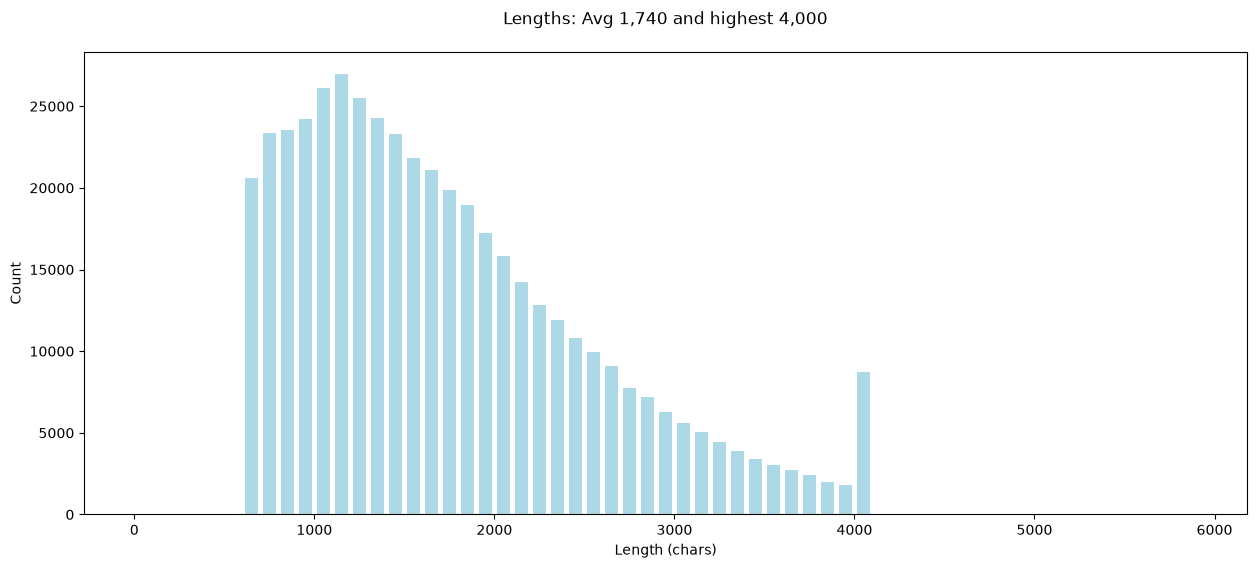

In [11]:
# Plot the distribution of lengths

plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [12]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

iPad Mini 6 Keyboard Case 2021, 7 Colors Backlit Detachable Keyboard Slim Folio Smart Cover for iPad Mini 6th 
Generation 8.3 inch – Black
BORIYUAN
['New iPad Mini 6 Keyboard Case 2021- Boriyuan 7 Colors Backlit Detachable Keyboard Slim Leather Folio Smart Cover 
with Pencil Holder for Apple iPad Mini 6th Gen 8.3"(A2567/A2568/A2569), Support Apple Pencil Charging', 
'Description:', "- Slim, sturdy and attractive design.The iPad fits snugly into the case and provide sufficient 
protections for daily use. - Our iPad Mini 6th generation keyboard case comes with a slot for holding your Apple 
pencil stylus that lets you effortlessly reach for your pen whenever you want to use the touch pen function.(Apple 
Pencil is NOT included) - A protective cover and real, quiet keyboard support 3 use modes - Typing, Viewing, 
Reading - giving you amazing versatility. It allows you to prop the iPad up for watching videos.Ideal for 
school&home& work & travel. - All your ipad needs in one tool.The Folio Case takes mobile computing to a new 
level.Now you can enjoy laptop-like typing anywhere you take your iPad. Its slim design make it a joy to use 
anywhere, anytime. - The iPad Mini 6 Case Support apple pencil's magnetic attachment and wireless charging without 
taking off the case. - With the Auto Sleep/Wake Function ,When open the smart cover, your iPad instantly wakes up; 
when close it, your iPad automatically goes to sleep. You can press any key to wake the keyboard up. - Perfect 
access to all ports/buttons and camera.", '* How to connect the Bluetooth?', '* Make sure the keyboard fully 
charged(usually 4-5hours) before first using. * Turn on the keyboard. * Click ""fn"" + ""C"" to open the Bluetooth 
of the keyboard. * Turn on the Bluetooth of your iPad. * Find the ""Bluetooth 3.0 Keyboard"" and select it, the 
Bluetooth will be connected automatically.', '* Packing List:', '1* iPad Case with Keyboard for iPad Mini 6 2021 
8.3 inch 1* Micro USB 2.0 Cable (ONLY for the keyboard, NOT for iPad) 1* User Manual']
['Compatibility】- Boriyuan Stylish iPad Mini 6th Gen Keyboard Case will turn your iPad into a stylish laptop in 
Seconds.It is uniquely ideal for school&home& work & travel. Specifilly designed for New iPad Mini 6 2021 8.3 
inch(Model Number: A2567 A2568 A2569), Not for any other iPad model.', '【Detachable & Backlit Bluetooth iPad Mini 
6 Keyboard】 - 3 levels of brightness and 7 vibrant colors make typing fun and easy in the dark or the light.The 
lightweight bluetooth keyboard is ultra slim and can be attached to the case magnetically, if not needed, it can be
removed.Bluetooth connectivity is easy.', '【Full Protection & Multiple Viewing Angles】- This keyboard case for 
iPad mini 6 is made of high quality PU leather material for durability, carrying a silicone soft shell inside, so 
that it can protect your tablet from being scratched, accidental dropping and bumps.Three dents on the case for 
propping up the tablet into three different viewing angles in landscape mode.Perfect for working, writing, or 
watching videos.', "【Built-in Apple Pencil Holder & Auto Sleep/ Wake Function】 - Our iPad Mini 6th generation 
keyboard case comes with a slot for holding your Apple pencil and can also support 2nd Gen Apple Pencil's magnetic 
attachment and wireless charging without taking off the case.(Apple Pencil is NOT included).It automatically wakes 
or puts your iPad to sleep when it is opened or closed,save much power for your iPad.", '【Package & Warranty - 
content includes】- 1 x keyboard case for ipad mini 6th generation 8.3 inch 2021, 1 x Micro USB charging cable,1 x 
user Manual.Boriyuan provides you with 24-hour email contact service and product warranty.']
{"Package Dimensions": "9.17 x 6.69 x 1.14 inches", "Item Weight": "1.12 pounds", "Manufacturer": "Boriyuan", 
"Country of Origin": "China", "Date First Available": "November 11, 2021", "Brand": "", "Compatible Devices": 
"Tablet", "Connectivity Technology": "Bluetooth, usb, Micro USB

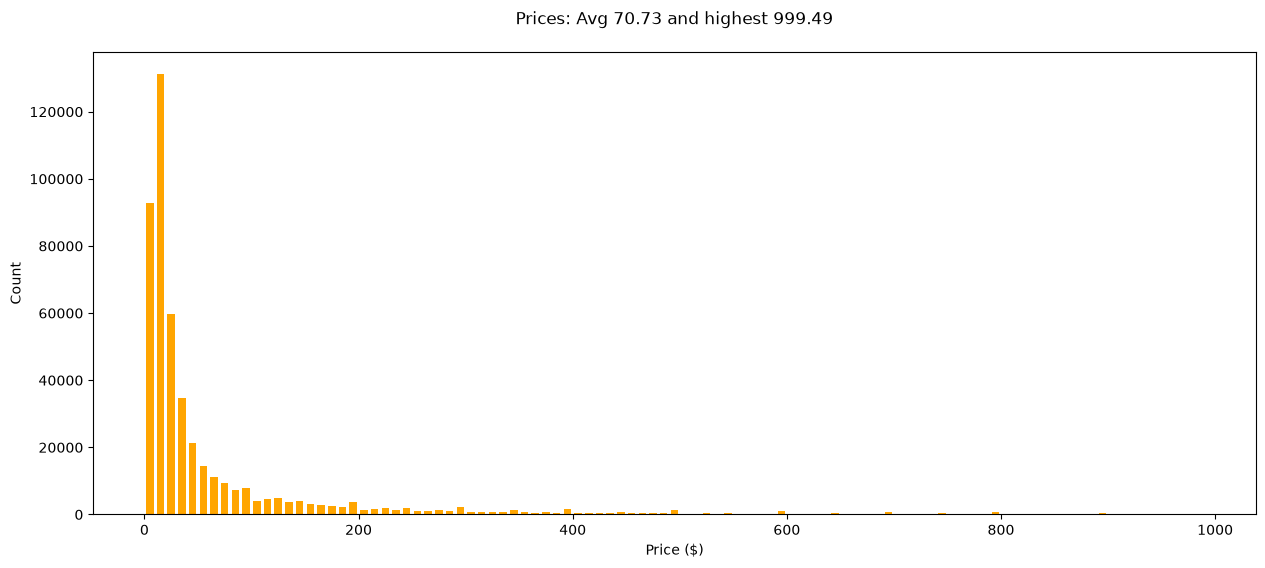

In [13]:
# Plot the distribution of prices
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [14]:
print(items[3].full)

QGHXO Band for Garmin Vivofit 4, Soft Silicone Replacement Watch Band Strap for Garmin Vivofit 4 Activity Tracker, 
Small, Large, Ten Colors (5PCS Bands-Girl, Large)
QGHXO
['Compatibility', 'Custom designed for your precious', 'Garmin Vivofit 4', 'Activity Tracker, this Garmin Watch 
Sport Band features a combination of functionality and style. Fit for', 'Garmin Vivofit 4', 'Activity Tracker ONLY.
NOT for Garmin Vivofit 1/Garmin Vivofit 2/Garmin Vivofit 3.', 'Feature', 'Material: Silicone. NOTE: Replacement 
Bands Only! Small fits wrists with a circumference of 122-188mm. Large fits wrists with a circumference of 
148-215mm. Models for selection: For Garmin Vivofit 4 Activity Tracker Only. Contracted design style, with you life
contracted and not simple.', 'Package Included', 'Soft Silicone Replacement Watch Band Strap for Garmin Vivofit 4 
Activity Tracker (No Tracker)']
['Personalized Your Garmin Vivofit 4 Activity Tracker with this refined replacement wrist band', 'Small fits wrists
with a circumference of 122-188mm. Large fits wrists with a circumference of 148-215mm', 'Easy and direct 
installation and removal. Replacement Bands Only! Garmin device NOT included', 'Garmin Vivofit 4 Buckle Bracelet. 
Never lose your Garmin Vivofit 4. Fix the tracker fall off problem', 'Soft silicone with smooth finish for a sporty
look, metal parts made with high quality stainless steel']
{"Package Dimensions": "6.85 x 4.37 x 1.1 inches", "Item Weight": "2.64 ounces", "Is Discontinued By Manufacturer":
"No", "Special features": "activity tracker", "Other display features": "Sports", "Color": "5PCS Bands-Girl", 
"Manufacturer": "QGHXO", "Date First Available": "March 17, 2018"}

In [15]:
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_root = project_root / "data/01-raw/Amazon-Reviews-2023"

dataset_names = sorted(
    p.name.replace("raw_meta_", "")
    for p in data_root.glob("raw_meta_*")
    if p.is_dir() and any(p.glob("*.parquet"))
)

print(f"Available locally: {dataset_names}")

Available locally: ['All_Beauty', 'Arts_Crafts_and_Sewing', 'Cell_Phones_and_Accessories', 'Electronics', 
'Industrial_and_Scientific', 'Toys_and_Games']

In [16]:
import price_agent.data.loaders as loaders

items = []
for dataset_name in dataset_names:
    category_folder = data_root / f"raw_meta_{dataset_name}"
    loader = loaders.ItemLoader(dataset_name)
    items.extend(loader.load(data_folder=str(category_folder)))

print(f"Loaded {len(items):,} items from {len(dataset_names)} local categories")

Loading dataset All_Beauty


2026-08-08 23:31:08,507 INFO httpx HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/parquet/parquet.py "HTTP/1.1 404 Not Found"
100%|██████████| 113/113 [00:09<00:00, 11.51it/s]


Completed All_Beauty with 5,807 datapoints in 0.2 mins
Loading dataset Arts_Crafts_and_Sewing


2026-08-08 23:31:21,323 INFO httpx HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/parquet/parquet.py "HTTP/1.1 404 Not Found"
100%|██████████| 802/802 [01:03<00:00, 12.69it/s]


Completed Arts_Crafts_and_Sewing with 312,171 datapoints in 1.2 mins
Loading dataset Cell_Phones_and_Accessories


...

2026-08-08 23:43:32,728 INFO httpx HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/parquet/parquet.py "HTTP/1.1 404 Not Found"
100%|██████████| 428/428 [01:43<00:00,  4.14it/s]


Completed Industrial_and_Scientific with 179,328 datapoints in 1.9 mins
Loading dataset Toys_and_Games


2026-08-08 23:45:25,417 INFO httpx HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/parquet/parquet.py "HTTP/1.1 404 Not Found"
100%|██████████| 891/891 [03:32<00:00,  4.20it/s]


Completed Toys_and_Games with 349,734 datapoints in 3.8 mins


Loaded 1,555,649 items from 6 local categories

In [17]:
print(f"A grand total of {len(items):,} items")

A grand total of 1,555,649 items

In [18]:
print(items[1000])

Item(
    title='Ruby Kiss Aqua BB 8 in 1 Multi Function Light (KBB00) by Kiss',
    category='All_Beauty',
    price=3.99,
    full='Ruby Kiss Aqua BB 8 in 1 Multi Function Light (KBB00) by Kiss\nKISS\n[\'Kiss New York 8-in-1 Multi 
Function Radiant finish Aqua Beauty Balm\', \'WHATIT IS\', \'A multi-functional BB balm that provides high coverage
with a radiant, glowy finish.\', \'WHATIT DOES\', \'Recommended For (Skin Concern/Type):\', \'Dry\', \'Dry\', 
\'Normal\', \'Normal\', \'Hyperpigmentation\', \'Hyperpigmentation\']\n[\'A multi-functional BB balm that provides 
high coverage with a radiant, glowy finish.\', \'A multi-functional BB balm that provides high coverage with a 
radiant, glowy finish.\', \'A multi-functional BB balm that provides high coverage with a radiant, glowy finish.\',
\'With this multi-functional and high performance beauty balm enriched with powerful brightening and youth-infused 
properties, you will save time with just one easy step.\', \'It naturally covers and conceals any imperfections, 
nourishes the skin with Vitamin B and E, and brightens your face by correcting uneven skin tone after continual 
use.\', \'Kiss New York 8-in-1 Multi Function Radiant finish Aqua Beauty Balm provides you with healthy-looking 
skin in an instant and is suitable for all skin types.\']\n{"Brand": "KISS", "Item Form": "Balm", "Unit Count": 
"1.00 Count", "Number of Items": "1", "Use for": "Whole Body", "Package Dimensions": "6.65 x 2.99 x 1.3 inches; 
2.54 Ounces", "UPC": "789764943203 731509635812"}',
    weight=0.0,
    summary=None,
    prompt=None,
    id=None,
    parent_asin='B01NAQDKWJ'
)

In [19]:
# de-duplication of data

random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")

  0%|          | 0/1555649 [00:00<?, ?it/s]

  0%|          | 0/1534204 [00:00<?, ?it/s]

After deduplication, we have 1,533,910 items

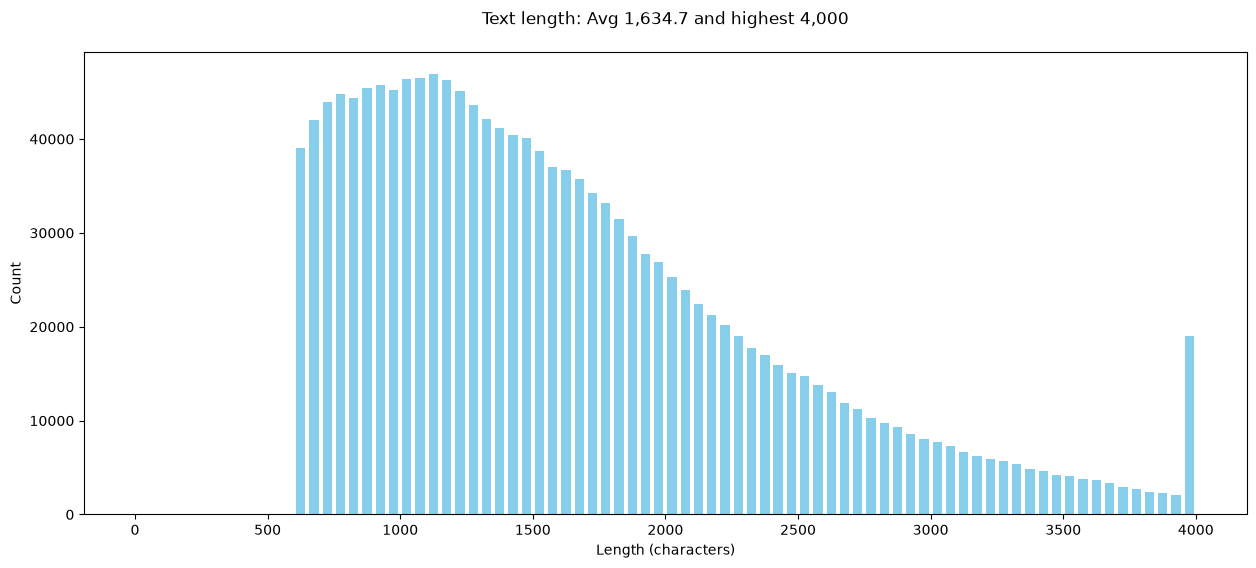

In [20]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.1f} and highest {max(lengths):,}\n")
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

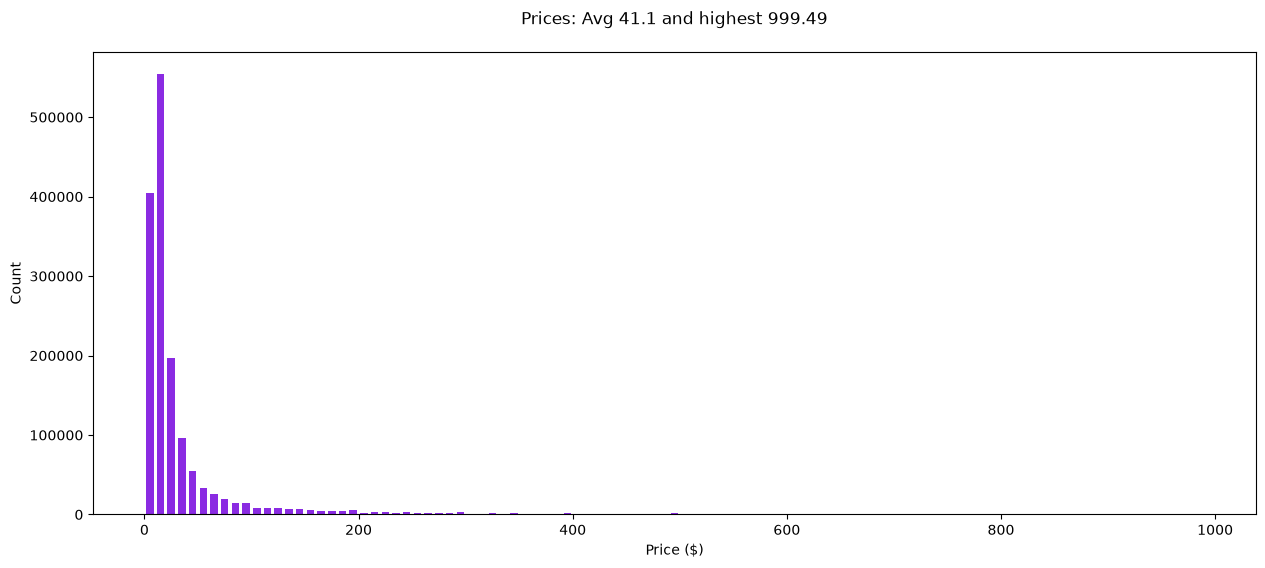

In [21]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

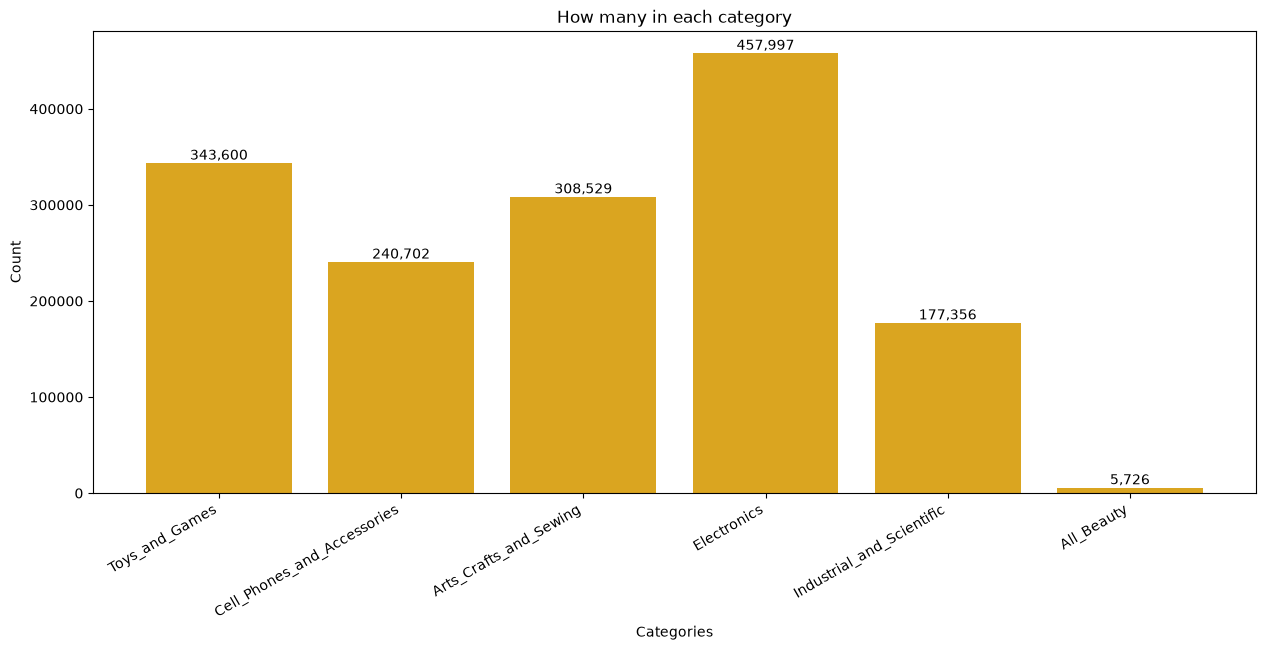

In [22]:
from collections import Counter
category_counts = Counter([item.category for item in items])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

In [23]:
np.random.seed(42)

SIZE = 820_000

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p**2
w[categories == "Electronics"] *= 0.5
w[categories == "Toys_and_Games"] *= 0.5

w = w / w.sum()
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]


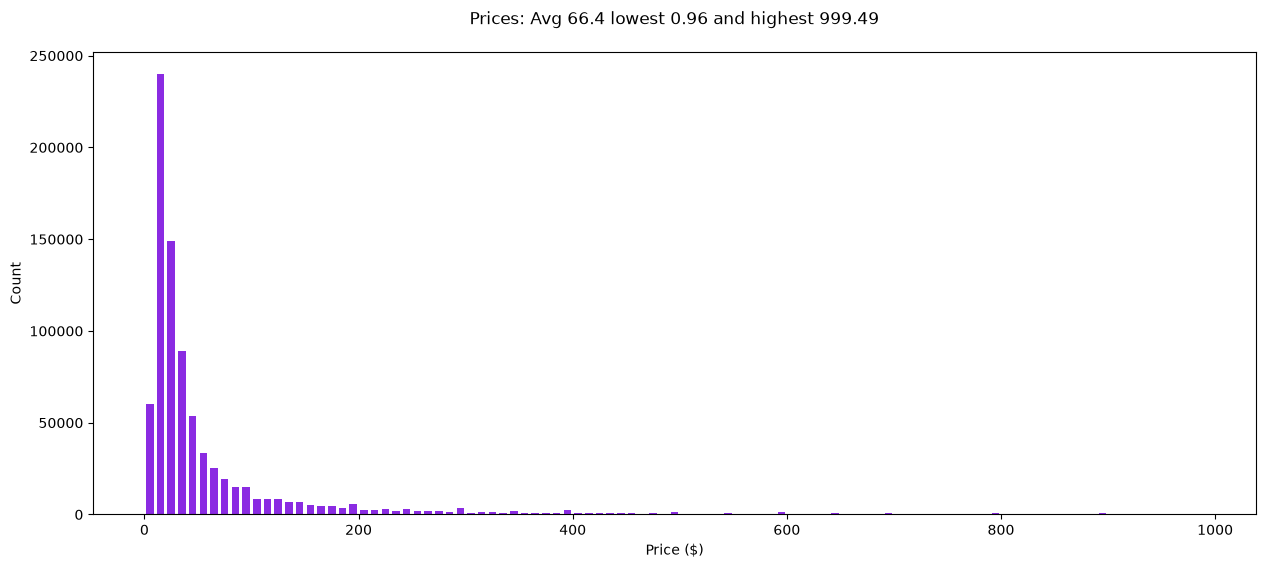

In [24]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [25]:
# Just for good measure, let's shuffle the sample again for the final dataset

random.seed(42)
random.shuffle(sample)

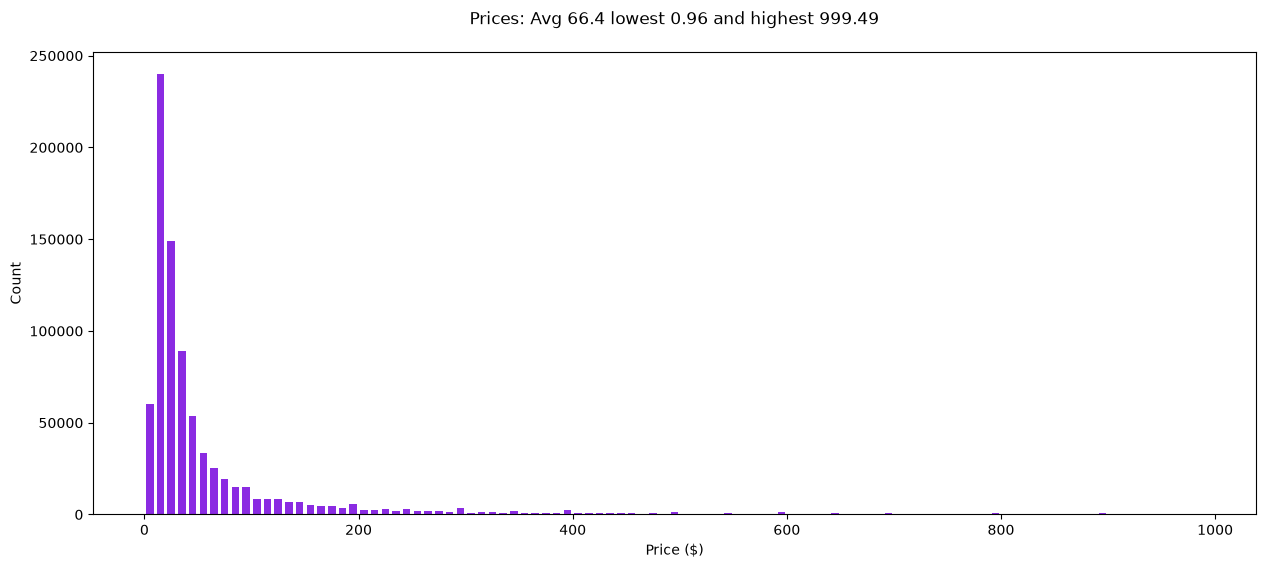

In [26]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

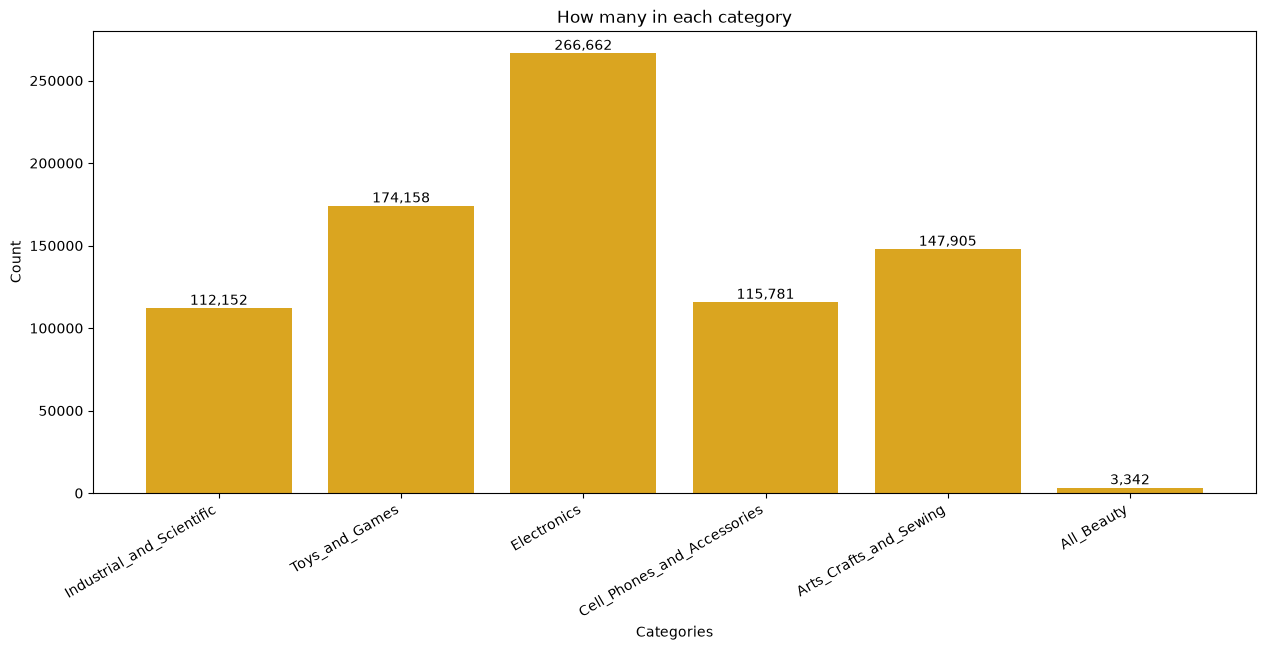

In [27]:
from collections import Counter
category_counts = Counter([item.category for item in sample])

categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

# Display the chart
plt.show()

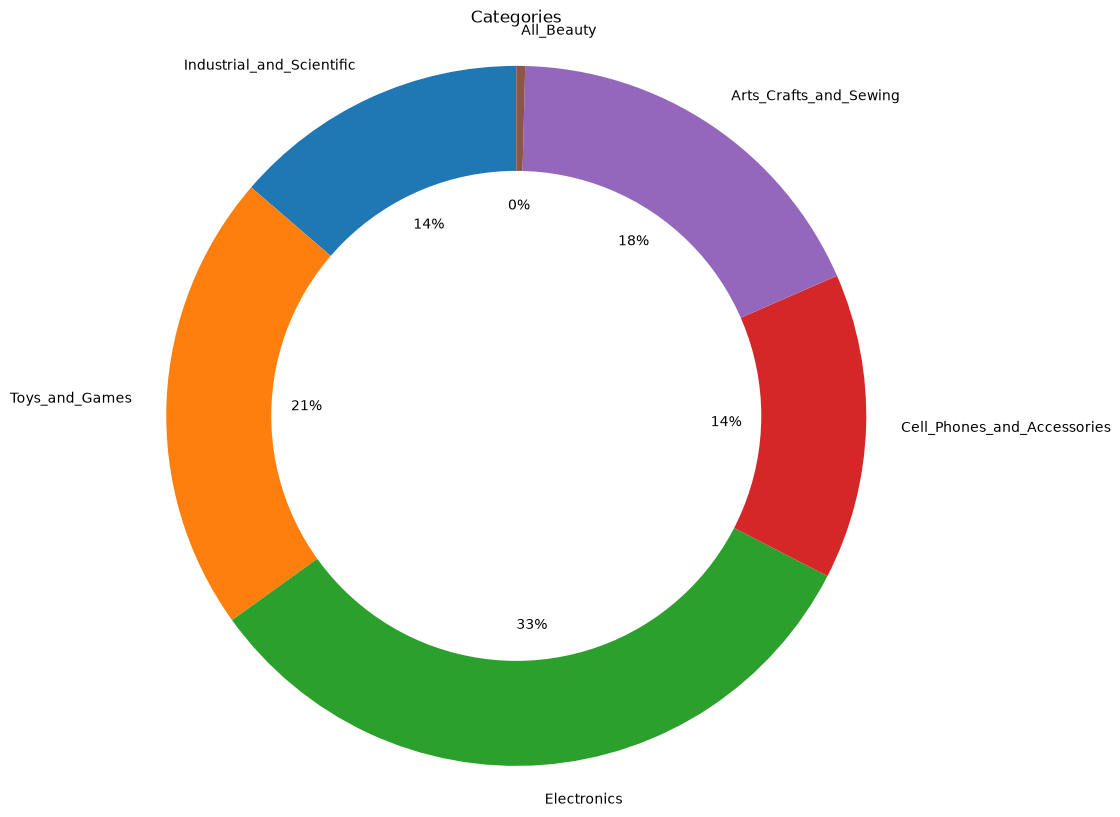

In [28]:
# Electronics still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')  

plt.show()

Preparing scatter data:   0%|          | 0/820000 [00:00<?, ?it/s]

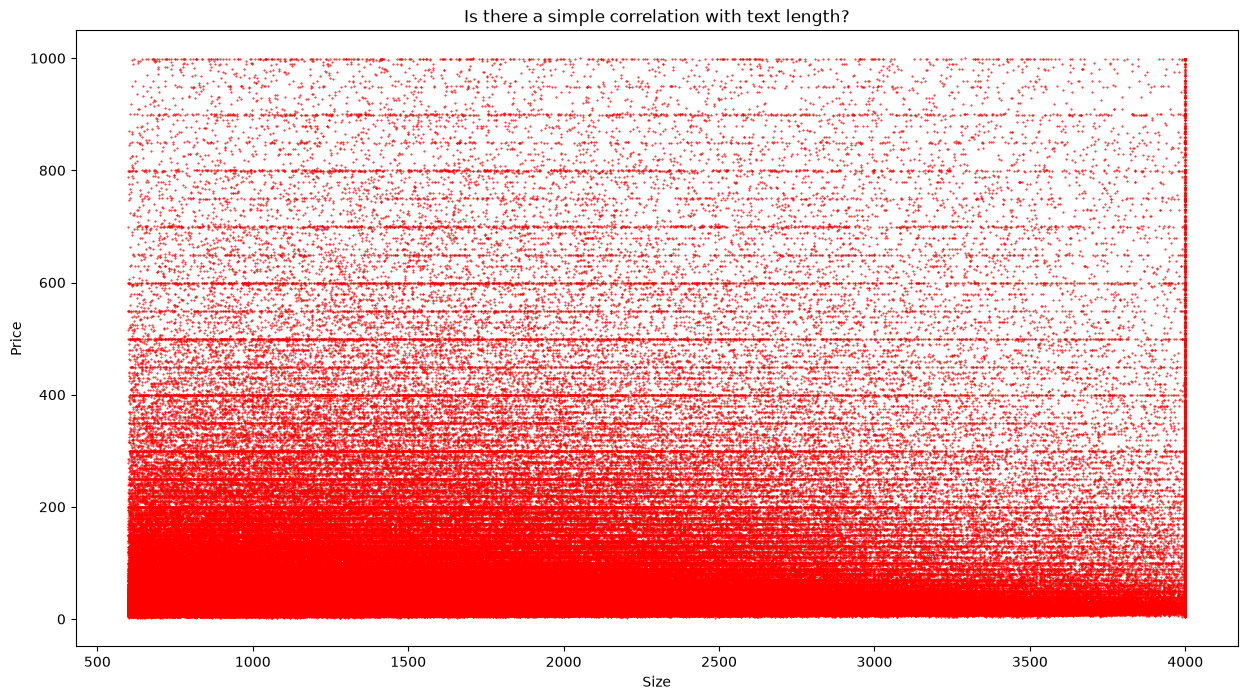

In [29]:
# How does the price vary with the character count?

sizes = []
prices = []
for item in tqdm(sample, desc="Preparing scatter data"):
    sizes.append(len(item.full))
    prices.append(item.price)

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation with text length?')

# Display the plot
plt.show()

Preparing weight scatter data:   0%|          | 0/820000 [00:00<?, ?it/s]

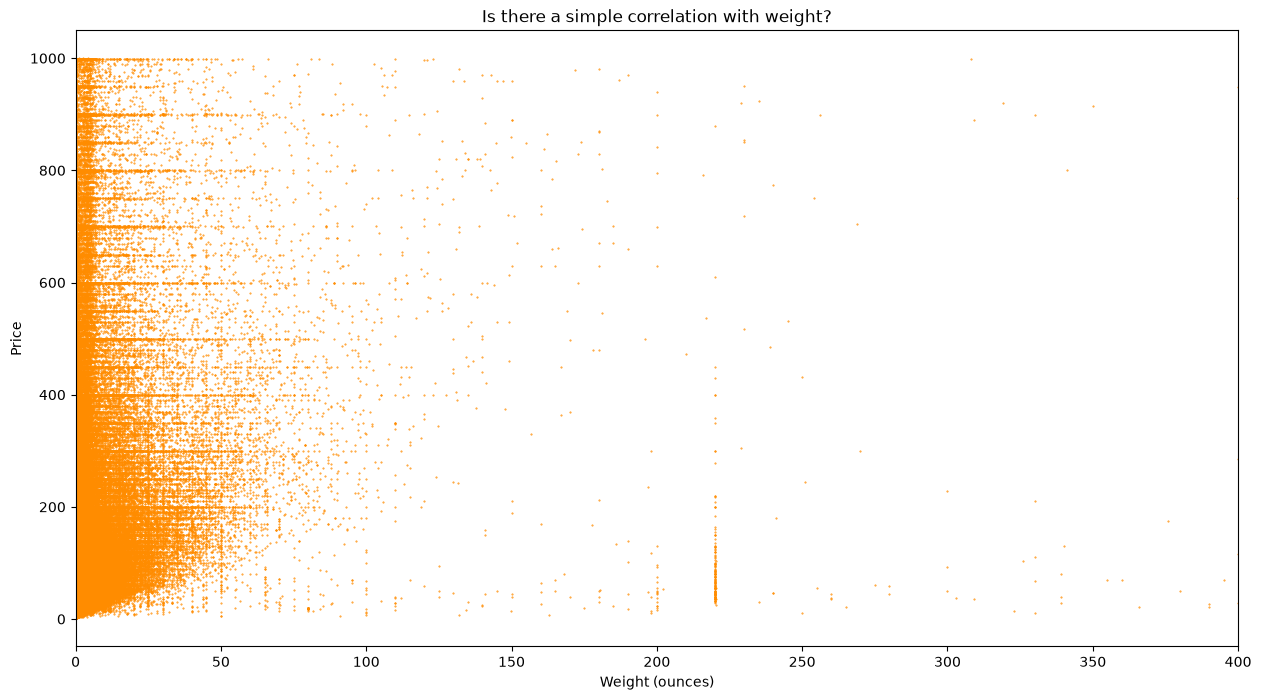

In [30]:
# How does the price vary with the weight?

ounces = []
prices = []
for item in tqdm(sample, desc="Preparing weight scatter data"):
    ounces.append(item.weight)
    prices.append(item.price)

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")

# Add labels and title
plt.xlabel('Weight (ounces)')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.title('Is there a simple correlation with weight?')

# Display the plot
plt.show()

In [31]:
# Now push the dataset to the HuggingFace Hub

username = "ujjwalsingh108"
full = f"{username}/items_raw_full"
lite = f"{username}/items_raw_lite"

train = sample[:800_000]
val = sample[800_000:810_000]
test = sample[810_000:]

Item.push_to_hub(full, train, val, test)

train_lite = train[:20_000]
val_lite = val[:1_000]
test_lite = test[:1_000]

Item.push_to_hub(lite, train_lite, val_lite, test_lite)

Uploading ujjwalsingh108/items_raw_full with train=800,000, validation=10,000, test=10,000 using max_shard_size=200MB


2026-08-09 00:09:44,167 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_raw_full "HTTP/1.1 200 OK"


Uploading the dataset shards:   0%|          | 0/8 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

2026-08-09 00:09:47,438 INFO httpx HTTP Request: POST https://huggingface.co/api/datasets/ujjwalsingh108/items_raw_full/preupload/main "HTTP/1.1 200 OK"


...

2026-08-09 00:13:00,749 INFO httpx HTTP Request: POST https://huggingface.co/api/datasets/ujjwalsingh108/items_raw_lite/preupload/main "HTTP/1.1 200 OK"


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

2026-08-09 00:13:04,350 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_raw_lite "HTTP/1.1 200 OK"
2026-08-09 00:13:04,630 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_raw_lite/revision/d9ddfff9e9ce8e6fdf19a74310644a0459e65ed8 "HTTP/1.1 200 OK"
2026-08-09 00:13:04,916 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_raw_lite/tree/d9ddfff9e9ce8e6fdf19a74310644a0459e65ed8/data?recursive=true&expand=false "HTTP/1.1 404 Not Found"
2026-08-09 00:13:05,196 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_raw_lite/tree/d9ddfff9e9ce8e6fdf19a74310644a0459e65ed8?recursive=false&expand=false "HTTP/1.1 200 OK"
2026-08-09 00:13:05,473 INFO httpx HTTP Request: GET https://huggingface.co/api/datasets/ujjwalsingh108/items_raw_lite/tree/d9ddfff9e9ce8e6fdf19a74310644a0459e65ed8/data?recursive=true&expand=false "HTTP/1.1 404 Not Found"
2026-08-09 00:13:0

Completed upload for ujjwalsingh108/items_raw_lite


### Sidenote

If you like the variety of colors that matplotlib can use in its charts, you should bookmark this:

https://matplotlib.org/stable/gallery/color/named_colors.html
